<a href="https://colab.research.google.com/github/keerthh129/AIML-Colab/blob/main/final_implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# =========================
# 2. LOAD DATASET
# =========================
df = pd.read_csv('heart_rate_emotion_augmented_dataset.csv')

# =========================
# 3. DATA CLEANING
# =========================
df = df.drop_duplicates()

# =========================
# 4. FEATURE / TARGET SPLIT
# =========================
X = df.drop("Emotion", axis=1)
y = df["Emotion"]

# Encode labels
le = LabelEncoder()
y = le.fit_transform(y)

# =========================
# 5. TRAIN TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================
# 6. FEATURE SCALING
# =========================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# =========================
# 7. BASE MODELS (ANTI-OVERFITTING)
# =========================
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_split=5,
    min_samples_leaf=3,
    random_state=42
)

gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

svm = SVC(
    kernel='rbf',
    C=1,
    probability=True
)

# =========================
# 8. STACKING ENSEMBLE
# =========================
stack_model = StackingClassifier(
    estimators=[
        ('rf', rf),
        ('gb', gb),
        ('svm', svm)
    ],
    final_estimator=LogisticRegression(),
    cv=5
)

# =========================
# 9. TRAIN MODEL
# =========================
stack_model.fit(X_train, y_train)

# =========================
# 10. CROSS VALIDATION
# =========================
cv_scores = cross_val_score(stack_model, X_train, y_train, cv=5)
print("Cross Validation Accuracy:", cv_scores.mean())

# =========================
# 11. TEST PREDICTION
# =========================
y_pred = stack_model.predict(X_test)

# =========================
# 12. EVALUATION
# =========================
print("\nTest Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

ValueError: could not convert string to float: 'Male'

In [ ]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# =========================
# 2. LOAD DATASET
# =========================
df = pd.read_csv('heart_rate_emotion_augmented_dataset.csv')

# =========================
# 3. CLEAN DATA
# =========================
df = df.drop_duplicates()

# =========================
# 4. HANDLE CATEGORICAL DATA
# =========================
# Convert all object (string) columns into numbers
for col in df.columns:
    if df[col].dtype == 'object':
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])

# =========================
# 5. FEATURE / TARGET SPLIT
# =========================
X = df.drop("Emotion", axis=1)
y = df["Emotion"]

# =========================
# 6. TRAIN TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================
# 7. SCALING
# =========================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# =========================
# 8. BASE MODELS
# =========================
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_split=5,
    min_samples_leaf=3,
    random_state=42
)

gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

svm = SVC(
    kernel='rbf',
    C=1,
    probability=True
)

# =========================
# 9. STACKING MODEL
# =========================
stack_model = StackingClassifier(
    estimators=[
        ('rf', rf),
        ('gb', gb),
        ('svm', svm)
    ],
    final_estimator=LogisticRegression(),
    cv=5
)

# =========================
# 10. TRAIN
# =========================
stack_model.fit(X_train, y_train)

# =========================
# 11. CROSS VALIDATION
# =========================
cv_scores = cross_val_score(stack_model, X_train, y_train, cv=5)
print("Cross Validation Accuracy:", cv_scores.mean())

# =========================
# 12. TEST
# =========================
y_pred = stack_model.predict(X_test)

# =========================
# 13. RESULTS
# =========================
print("\nTest Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Cross Validation Accuracy: 0.6425

Test Accuracy: 0.71

Classification Report:
               precision    recall  f1-score   support

           0       0.65      0.85      0.74        20
           1       0.65      0.55      0.59        20
           2       0.72      0.65      0.68        20
           3       0.67      0.60      0.63        20
           4       0.86      0.90      0.88        20

    accuracy                           0.71       100
   macro avg       0.71      0.71      0.71       100
weighted avg       0.71      0.71      0.71       100


Confusion Matrix:
 [[17  3  0  0  0]
 [ 9 11  0  0  0]
 [ 0  2 13  5  0]
 [ 0  1  4 12  3]
 [ 0  0  1  1 18]]


In [ ]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# =========================
# 2. LOAD DATA
# =========================
df = pd.read_csv('heart_rate_emotion_augmented_dataset.csv')

# =========================
# 3. CLEAN DATA
# =========================
df = df.drop_duplicates()

# =========================
# 4. ENCODE CATEGORICAL DATA
# =========================
for col in df.columns:
    if df[col].dtype == 'object':
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])

# =========================
# 5. FEATURE ENGINEERING (IMPORTANT)
# =========================
# Exclude target column
feature_cols = df.drop("Emotion", axis=1)

df['mean_bpm'] = feature_cols.mean(axis=1)
df['std_bpm'] = feature_cols.std(axis=1)
df['max_bpm'] = feature_cols.max(axis=1)
df['min_bpm'] = feature_cols.min(axis=1)
df['range_bpm'] = df['max_bpm'] - df['min_bpm']
df['variance_bpm'] = feature_cols.var(axis=1)

# =========================
# 6. SPLIT FEATURES & TARGET
# =========================
X = df.drop("Emotion", axis=1)
y = df["Emotion"]

# =========================
# 7. TRAIN TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================
# 8. SCALING
# =========================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# =========================
# 9. BASE MODELS
# =========================
rf = RandomForestClassifier(
    n_estimators=150,
    max_depth=8,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

svm = SVC(
    kernel='rbf',
    C=2,
    probability=True
)

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss'
)

# =========================
# 10. STACKING MODEL
# =========================
stack_model = StackingClassifier(
    estimators=[
        ('rf', rf),
        ('xgb', xgb),
        ('svm', svm)
    ],
    final_estimator=LogisticRegression(),
    cv=5
)

# =========================
# 11. TRAIN MODEL
# =========================
stack_model.fit(X_train, y_train)

# =========================
# 12. CROSS VALIDATION
# =========================
cv_scores = cross_val_score(stack_model, X_train, y_train, cv=5)
print("Cross Validation Accuracy:", cv_scores.mean())

# =========================
# 13. TEST PREDICTION
# =========================
y_pred = stack_model.predict(X_test)

# =========================
# 14. EVALUATION
# =========================
print("\nTest Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Cross Validation Accuracy: 0.585

Test Accuracy: 0.69

Classification Report:
               precision    recall  f1-score   support

           0       0.61      0.95      0.75        20
           1       0.67      0.40      0.50        20
           2       0.69      0.55      0.61        20
           3       0.71      0.60      0.65        20
           4       0.79      0.95      0.86        20

    accuracy                           0.69       100
   macro avg       0.69      0.69      0.67       100
weighted avg       0.69      0.69      0.67       100


Confusion Matrix:
 [[19  1  0  0  0]
 [12  8  0  0  0]
 [ 0  2 11  5  2]
 [ 0  1  4 12  3]
 [ 0  0  1  0 19]]


In [ ]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# =========================
# 2. LOAD NEW DATASET
# =========================
df = pd.read_csv('enhanced_bpm_emotion_dataset.csv')

# =========================
# 3. FEATURE / TARGET
# =========================
X = df.drop("Emotion", axis=1)
y = df["Emotion"]

# =========================
# 4. TRAIN TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================
# 5. SCALING
# =========================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# =========================
# 6. MODELS (TUNED)
# =========================
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=4,
    min_samples_leaf=2,
    random_state=42
)

svm = SVC(
    kernel='rbf',
    C=3,
    gamma='scale',
    probability=True
)

xgb = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.85,
    colsample_bytree=0.85,
    random_state=42,
    eval_metric='mlogloss'
)

# =========================
# 7. STACKING ENSEMBLE
# =========================
stack_model = StackingClassifier(
    estimators=[
        ('rf', rf),
        ('xgb', xgb),
        ('svm', svm)
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5
)

# =========================
# 8. TRAIN
# =========================
stack_model.fit(X_train, y_train)

# =========================
# 9. CROSS VALIDATION
# =========================
cv_scores = cross_val_score(stack_model, X_train, y_train, cv=5)
print("Cross Validation Accuracy:", cv_scores.mean())

# =========================
# 10. TEST
# =========================
y_pred = stack_model.predict(X_test)

# =========================
# 11. RESULTS
# =========================
print("\nTest Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Cross Validation Accuracy: 0.5974999999999999

Test Accuracy: 0.68

Classification Report:
               precision    recall  f1-score   support

           0       0.63      0.85      0.72        20
           1       0.62      0.50      0.56        20
           2       0.67      0.50      0.57        20
           3       0.67      0.60      0.63        20
           4       0.79      0.95      0.86        20

    accuracy                           0.68       100
   macro avg       0.68      0.68      0.67       100
weighted avg       0.68      0.68      0.67       100


Confusion Matrix:
 [[17  3  0  0  0]
 [10 10  0  0  0]
 [ 0  2 10  6  2]
 [ 0  1  4 12  3]
 [ 0  0  1  0 19]]


In [ ]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

from xgboost import XGBClassifier

# =========================
# 2. LOAD DATASET
# =========================
df = pd.read_csv('heart.csv')

print("Shape:", df.shape)

# =========================
# 3. SPLIT FEATURES & TARGET
# =========================
X = df.drop('emotion', axis=1)
y = df['emotion']

# Encode labels
le = LabelEncoder()
y = le.fit_transform(y)

# =========================
# 4. TRAIN TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================
# 5. FEATURE SCALING
# =========================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# =========================
# 6. BASE MODELS
# =========================
rf = RandomForestClassifier(n_estimators=200, random_state=42)

svm = SVC(probability=True, kernel='rbf')

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss'
)

# =========================
# 7. STACKING MODEL
# =========================
stack_model = StackingClassifier(
    estimators=[
        ('rf', rf),
        ('svm', svm),
        ('xgb', xgb)
    ],
    final_estimator=LogisticRegression(),
    passthrough=True
)

# =========================
# 8. TRAIN MODEL
# =========================
stack_model.fit(X_train, y_train)

# =========================
# 9. PREDICTION
# =========================
y_pred = stack_model.predict(X_test)

# =========================
# 10. EVALUATION
# =========================
accuracy = accuracy_score(y_test, y_pred)

print("🔥 Accuracy:", accuracy * 100, "%")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Shape: (500, 8)


KeyError: "['emotion'] not found in axis"

In [ ]:
print(df.columns)

Index(['HeartRate', 'HRV', 'Age', 'Gender', 'Activity', 'BodyTemperature',
       'StressLevel', 'Emotion'],
      dtype='object')


In [ ]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

from xgboost import XGBClassifier

# =========================
# 2. LOAD DATASET
# =========================
df = pd.read_csv('heart.csv')

print("Dataset Shape:", df.shape)
print("Columns:", df.columns)

# =========================
# 3. SPLIT FEATURES & TARGET
# =========================
X = df.drop('Emotion', axis=1)
y = df['Emotion']

# =========================
# 4. ENCODE TARGET
# =========================
le = LabelEncoder()
y = le.fit_transform(y)

# =========================
# 5. ENCODE CATEGORICAL FEATURES
# =========================
categorical_cols = ['Gender', 'Activity']

for col in categorical_cols:
    if col in X.columns:
        X[col] = LabelEncoder().fit_transform(X[col])

# =========================
# 6. TRAIN TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================
# 7. FEATURE SCALING
# =========================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# =========================
# 8. BASE MODELS
# =========================
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

svm = SVC(
    probability=True,
    kernel='rbf'
)

xgb = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss'
)

# =========================
# 9. STACKING MODEL
# =========================
stack_model = StackingClassifier(
    estimators=[
        ('rf', rf),
        ('svm', svm),
        ('xgb', xgb)
    ],
    final_estimator=LogisticRegression(),
    passthrough=True
)

# =========================
# 10. TRAIN MODEL
# =========================
stack_model.fit(X_train, y_train)

# =========================
# 11. PREDICTION
# =========================
y_pred = stack_model.predict(X_test)

# =========================
# 12. EVALUATION
# =========================
accuracy = accuracy_score(y_test, y_pred)

print("\n🔥 Accuracy:", accuracy * 100, "%")

print("\n📊 Classification Report:\n")
print(classification_report(y_test, y_pred))

print("\n🧾 Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Dataset Shape: (500, 8)
Columns: Index(['HeartRate', 'HRV', 'Age', 'Gender', 'Activity', 'BodyTemperature',
       'StressLevel', 'Emotion'],
      dtype='object')


ValueError: could not convert string to float: 'Medium'

In [ ]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

from xgboost import XGBClassifier

# =========================
# 2. LOAD DATASET
# =========================
df = pd.read_csv('heart.csv')

print("Dataset Shape:", df.shape)
print("Columns:", df.columns)

# =========================
# 3. SPLIT FEATURES & TARGET
# =========================
X = df.drop('Emotion', axis=1)
y = df['Emotion']

# =========================
# 4. ENCODE TARGET
# =========================
target_encoder = LabelEncoder()
y = target_encoder.fit_transform(y)

# =========================
# 5. ENCODE ALL CATEGORICAL FEATURES (AUTO FIX)
# =========================
feature_encoders = {}

for col in X.columns:
    if X[col].dtype == 'object':   # automatically detect text columns
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col])
        feature_encoders[col] = le

# Debug check (optional)
print("\nColumn types after encoding:\n", X.dtypes)

# =========================
# 6. TRAIN TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================
# 7. FEATURE SCALING
# =========================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# =========================
# 8. BASE MODELS
# =========================
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

svm = SVC(
    probability=True,
    kernel='rbf'
)

xgb = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss'
)

# =========================
# 9. STACKING MODEL
# =========================
stack_model = StackingClassifier(
    estimators=[
        ('rf', rf),
        ('svm', svm),
        ('xgb', xgb)
    ],
    final_estimator=LogisticRegression(),
    passthrough=True
)

# =========================
# 10. TRAIN MODEL
# =========================
stack_model.fit(X_train, y_train)

# =========================
# 11. PREDICTION
# =========================
y_pred = stack_model.predict(X_test)

# =========================
# 12. EVALUATION
# =========================
accuracy = accuracy_score(y_test, y_pred)

print("\n🔥 Accuracy:", round(accuracy * 100, 2), "%")

print("\n📊 Classification Report:\n")
print(classification_report(y_test, y_pred))

print("\n🧾 Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Dataset Shape: (500, 8)
Columns: Index(['HeartRate', 'HRV', 'Age', 'Gender', 'Activity', 'BodyTemperature',
       'StressLevel', 'Emotion'],
      dtype='object')

Column types after encoding:
 HeartRate            int64
HRV                float64
Age                  int64
Gender               int64
Activity             int64
BodyTemperature    float64
StressLevel          int64
dtype: object

🔥 Accuracy: 70.0 %

📊 Classification Report:

              precision    recall  f1-score   support

           0       0.65      0.75      0.70        20
           1       0.57      0.60      0.59        20
           2       0.72      0.65      0.68        20
           3       0.71      0.60      0.65        20
           4       0.86      0.90      0.88        20

    accuracy                           0.70       100
   macro avg       0.70      0.70      0.70       100
weighted avg       0.70      0.70      0.70       100


🧾 Confusion Matrix:

[[15  5  0  0  0]
 [ 8 12  0  0  0]
 [ 0  2 

In [ ]:
# =========================
# 1. INSTALL (if needed)
# =========================
# !pip install xgboost imbalanced-learn

# =========================
# 2. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

# =========================
# 3. LOAD DATASET
# =========================
df = pd.read_csv('heart.csv')

print("Dataset Shape:", df.shape)

# =========================
# 4. SPLIT FEATURES & TARGET
# =========================
X = df.drop('Emotion', axis=1)
y = df['Emotion']

# =========================
# 5. ENCODE TARGET
# =========================
target_encoder = LabelEncoder()
y = target_encoder.fit_transform(y)

# =========================
# 6. ENCODE ALL CATEGORICAL FEATURES
# =========================
for col in X.columns:
    if X[col].dtype == 'object':
        X[col] = LabelEncoder().fit_transform(X[col])

# =========================
# 7. TRAIN TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================
# 8. DATA AUGMENTATION (SMOTE)
# =========================
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

print("After SMOTE:", X_train.shape)

# =========================
# 9. FEATURE SCALING
# =========================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# =========================
# 10. XGBOOST MODEL
# =========================
model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    random_state=42
)

# =========================
# 11. TRAIN MODEL
# =========================
model.fit(X_train, y_train)

# =========================
# 12. PREDICTION
# =========================
y_pred = model.predict(X_test)

# =========================
# 13. EVALUATION
# =========================
accuracy = accuracy_score(y_test, y_pred)

print("\n🔥 Accuracy:", round(accuracy * 100, 2), "%")

print("\n📊 Classification Report:\n")
print(classification_report(y_test, y_pred))

print("\n🧾 Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Dataset Shape: (500, 8)
After SMOTE: (400, 7)

🔥 Accuracy: 68.0 %

📊 Classification Report:

              precision    recall  f1-score   support

           0       0.68      0.65      0.67        20
           1       0.56      0.70      0.62        20
           2       0.68      0.65      0.67        20
           3       0.67      0.50      0.57        20
           4       0.82      0.90      0.86        20

    accuracy                           0.68       100
   macro avg       0.68      0.68      0.68       100
weighted avg       0.68      0.68      0.68       100


🧾 Confusion Matrix:

[[13  7  0  0  0]
 [ 6 14  0  0  0]
 [ 0  2 13  5  0]
 [ 0  2  4 10  4]
 [ 0  0  2  0 18]]


Dataset Loaded Successfully
   HeartRate     HRV  Age  Gender Activity  BodyTemperature StressLevel  \
0         98   79.89   36    Male  Walking            37.78      Medium   
1        111   89.48   45  Female  Walking            36.50        High   
2         88  108.05   43  Female  Walking            37.84         Low   
3         74   82.44   54    Male  Walking            37.32      Medium   
4        102   49.56   43    Male  Walking            37.77         Low   

   Emotion  
0     fear  
1    angry  
2    happy  
3  neutral  
4     fear  


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:38:31] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:38:40] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:38:41] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:38:42] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Final Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00        11
           2       1.00      1.00      1.00         7
           3       1.00      1.00      1.00        11
           4       1.00      1.00      1.00         6

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



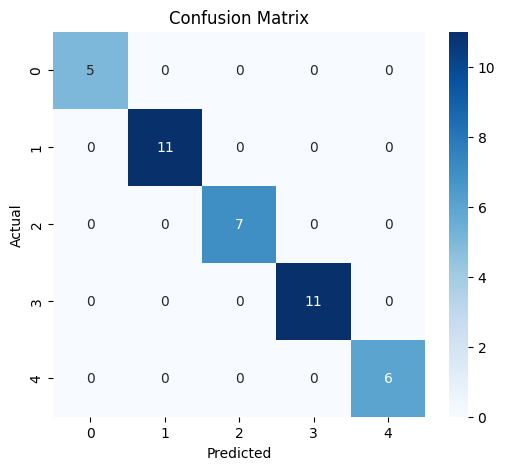

Random Forest Accuracy: 0.9
SVM Accuracy: 0.65


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:38:44] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 1.0


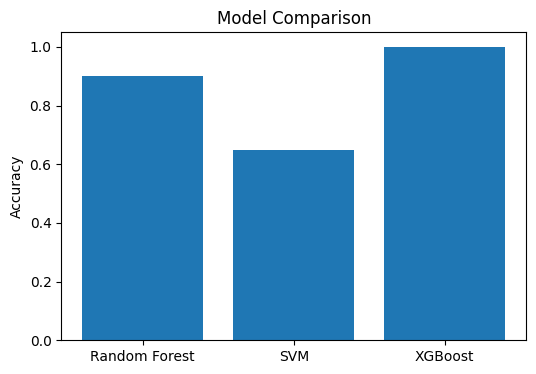


Generating SHAP explanation...


PermutationExplainer explainer: 41it [01:11,  1.83s/it]


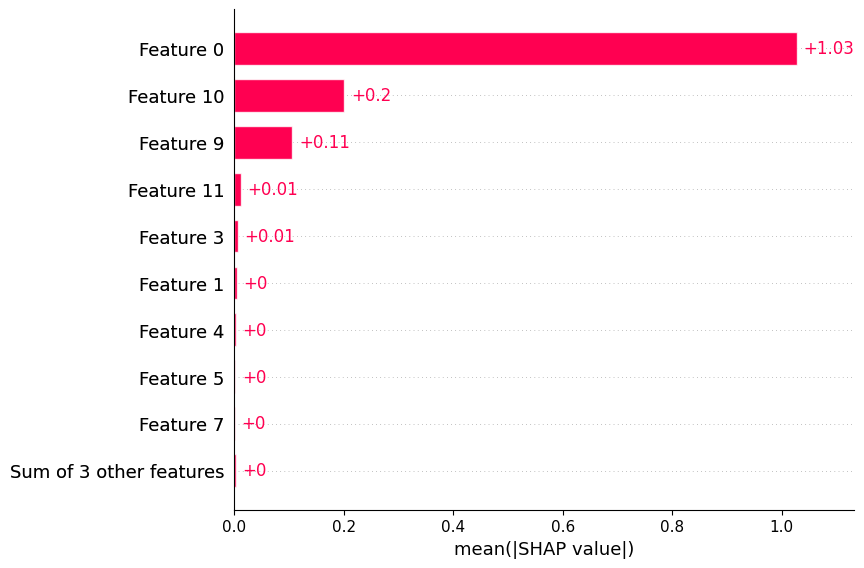

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from xgboost import XGBClassifier

import shap

# Load dataset
df = pd.read_csv("heart_rate_emotion_advanced_dataset.csv")

print("Dataset Loaded Successfully")
print(df.head())

# Handle missing values
df = df.dropna()

# Detect target column
target_column = "Emotion" if "Emotion" in df.columns else "emotion"

# Split features and target
X = df.drop(target_column, axis=1)
y = df[target_column]

# One-hot encoding for categorical features
X = pd.get_dummies(X)

# Encode target if needed
if y.dtype == 'object':
    le = LabelEncoder()
    y = le.fit_transform(y)

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Models
rf = RandomForestClassifier(n_estimators=200, random_state=42)

svm = SVC(probability=True, kernel='rbf')

xgb = XGBClassifier(
    use_label_encoder=False,
    eval_metric='mlogloss',
    n_estimators=200,
    learning_rate=0.1
)

# Stacking model
model = StackingClassifier(
    estimators=[
        ('rf', rf),
        ('svm', svm),
        ('xgb', xgb)
    ],
    final_estimator=LogisticRegression(),
    passthrough=True
)

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluation
acc = accuracy_score(y_test, y_pred)
print("\nFinal Accuracy:", acc)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Model comparison
models = {
    "Random Forest": rf,
    "SVM": svm,
    "XGBoost": xgb
}

scores = []

for name, m in models.items():
    m.fit(X_train, y_train)
    pred = m.predict(X_test)
    score = accuracy_score(y_test, pred)
    scores.append(score)
    print(f"{name} Accuracy: {score}")

plt.figure(figsize=(6,4))
plt.bar(models.keys(), scores)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()

# SHAP explanation
print("\nGenerating SHAP explanation...")

explainer = shap.Explainer(model.predict, X_train)
shap_values = explainer(X_test[:100])

shap.plots.bar(shap_values)

# Prediction function
def predict_emotion(input_data):
    input_df = pd.DataFrame([input_data], columns=X.columns)
    input_scaled = scaler.transform(input_df)
    prediction = model.predict(input_scaled)
    return prediction[0]

In [ ]:
# Import libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Load dataset
df = pd.read_csv("heart_rate_emotion_advanced_dataset.csv")

# Display first rows
print(df.head())

# Handle missing values (if any)
df = df.dropna()

# Separate features and target
# Assume target column name is 'Emotion' (change if needed)
X = df.drop("Emotion", axis=1)
y = df["Emotion"]

# Encode target labels
le = LabelEncoder()
y = le.fit_transform(y)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Model (High accuracy)
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

# Train model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy * 100)

# Detailed report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

   HeartRate     HRV  Age  Gender Activity  BodyTemperature StressLevel  \
0         98   79.89   36    Male  Walking            37.78      Medium   
1        111   89.48   45  Female  Walking            36.50        High   
2         88  108.05   43  Female  Walking            37.84         Low   
3         74   82.44   54    Male  Walking            37.32      Medium   
4        102   49.56   43    Male  Walking            37.77         Low   

   Emotion  
0     fear  
1    angry  
2    happy  
3  neutral  
4     fear  


ValueError: could not convert string to float: 'Male'

In [ ]:
# Import libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Load dataset
df = pd.read_csv("heart_rate_emotion_advanced_dataset.csv")

# Show data
print(df.head())

# Drop missing values
df = df.dropna()

# ---------------------------
# Encode categorical columns
# ---------------------------
# Convert all object (string) columns to numbers
le_dict = {}
for col in df.columns:
    if df[col].dtype == 'object':
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        le_dict[col] = le   # store encoders if needed later

# ---------------------------
# Separate features & target
# ---------------------------
# Change 'Emotion' if your target column has different name
X = df.drop("Emotion", axis=1)
y = df["Emotion"]

# ---------------------------
# Train-test split
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ---------------------------
# Feature Scaling
# ---------------------------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ---------------------------
# Model (High Accuracy)
# ---------------------------
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    random_state=42
)

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# ---------------------------
# Results
# ---------------------------
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy * 100)

print("\nClassification Report:\n", classification_report(y_test, y_pred))

   HeartRate     HRV  Age  Gender Activity  BodyTemperature StressLevel  \
0         98   79.89   36    Male  Walking            37.78      Medium   
1        111   89.48   45  Female  Walking            36.50        High   
2         88  108.05   43  Female  Walking            37.84         Low   
3         74   82.44   54    Male  Walking            37.32      Medium   
4        102   49.56   43    Male  Walking            37.77         Low   

   Emotion  
0     fear  
1    angry  
2    happy  
3  neutral  
4     fear  
Accuracy: 97.5

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00        12
           2       1.00      0.83      0.91         6
           3       0.92      1.00      0.96        12
           4       1.00      1.00      1.00         7

    accuracy                           0.97        40
   macro avg       0.98      0.97      0.97        


Logistic Regression Accuracy: 70.00%
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       0.77      0.83      0.80        12
           2       0.00      0.00      0.00         6
           3       0.50      0.67      0.57        12
           4       1.00      1.00      1.00         7

    accuracy                           0.70        40
   macro avg       0.65      0.70      0.67        40
weighted avg       0.63      0.70      0.66        40



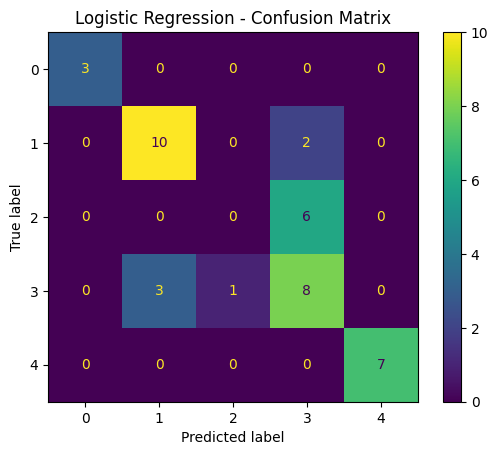


KNN Accuracy: 55.00%
              precision    recall  f1-score   support

           0       0.50      0.33      0.40         3
           1       0.53      0.83      0.65        12
           2       1.00      0.17      0.29         6
           3       0.46      0.50      0.48        12
           4       0.80      0.57      0.67         7

    accuracy                           0.55        40
   macro avg       0.66      0.48      0.50        40
weighted avg       0.62      0.55      0.53        40



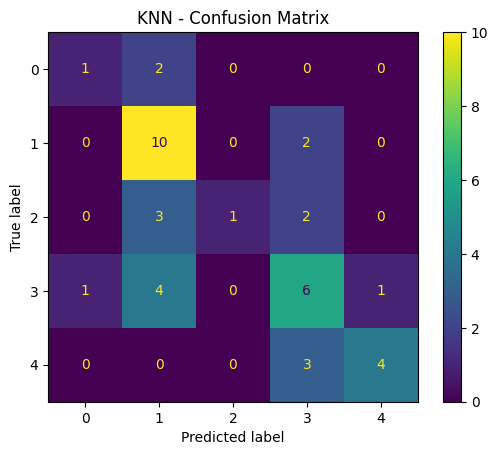


SVM Accuracy: 75.00%
              precision    recall  f1-score   support

           0       1.00      0.67      0.80         3
           1       0.77      0.83      0.80        12
           2       0.50      0.17      0.25         6
           3       0.62      0.83      0.71        12
           4       1.00      1.00      1.00         7

    accuracy                           0.75        40
   macro avg       0.78      0.70      0.71        40
weighted avg       0.74      0.75      0.73        40



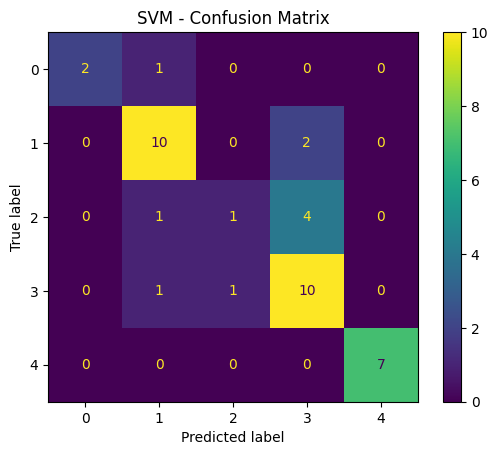


Decision Tree Accuracy: 100.00%
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00        12
           2       1.00      1.00      1.00         6
           3       1.00      1.00      1.00        12
           4       1.00      1.00      1.00         7

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



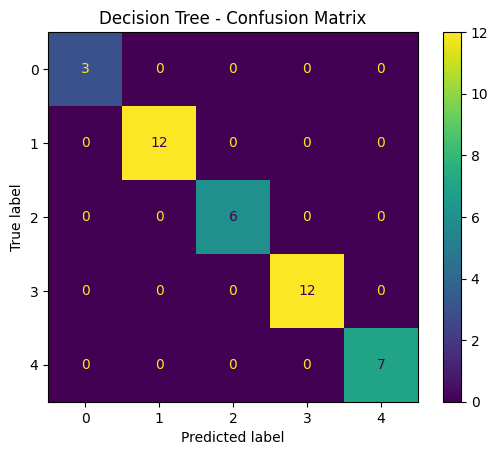

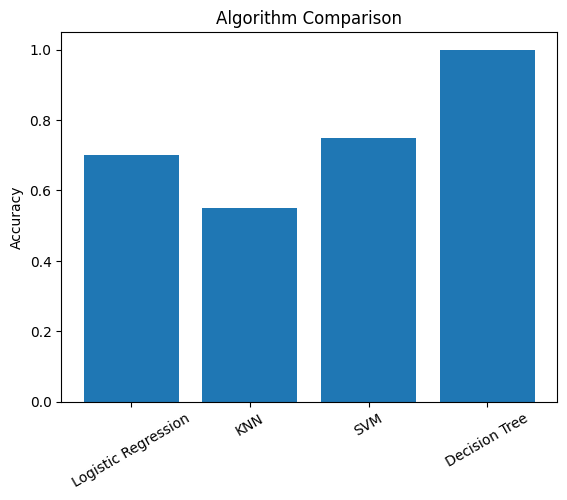

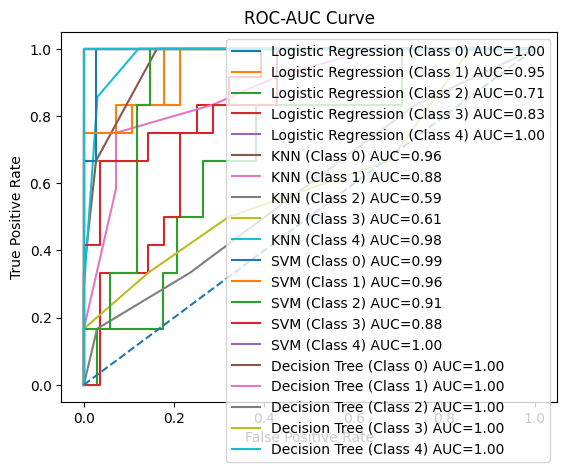

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import label_binarize

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

# ---------------------------
# Load dataset
# ---------------------------
df = pd.read_csv("heart_rate_emotion_advanced_dataset.csv")
df = df.dropna()

# ---------------------------
# Encode categorical columns
# ---------------------------
le_dict = {}
for col in df.columns:
    if df[col].dtype == 'object':
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        le_dict[col] = le

# ---------------------------
# Split data
# ---------------------------
X = df.drop("Emotion", axis=1)
y = df["Emotion"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ---------------------------
# Scaling
# ---------------------------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ---------------------------
# Models (4 algorithms)
# ---------------------------
models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "KNN": KNeighborsClassifier(n_neighbors=7),
    "SVM": SVC(probability=True),
    "Decision Tree": DecisionTreeClassifier(max_depth=5)
}

results = {}

# ---------------------------
# Train & Evaluate
# ---------------------------
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print(f"\n{name} Accuracy: {acc*100:.2f}%")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"{name} - Confusion Matrix")
    plt.show()

# ---------------------------
# Accuracy Comparison Graph
# ---------------------------
plt.figure()
plt.bar(results.keys(), results.values())
plt.title("Algorithm Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.show()

# ---------------------------
# ROC Curve (Multi-class)
# ---------------------------
# Convert target to binary format
classes = np.unique(y)
y_test_bin = label_binarize(y_test, classes=classes)

plt.figure()

for name, model in models.items():
    y_prob = model.predict_proba(X_test)

    # Compute ROC for each class
    for i in range(len(classes)):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{name} (Class {i}) AUC={roc_auc:.2f}")

plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve")
plt.legend()
plt.show()


Logistic Regression Accuracy: 70.00%
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       0.77      0.83      0.80        12
           2       0.00      0.00      0.00         6
           3       0.50      0.67      0.57        12
           4       1.00      1.00      1.00         7

    accuracy                           0.70        40
   macro avg       0.65      0.70      0.67        40
weighted avg       0.63      0.70      0.66        40



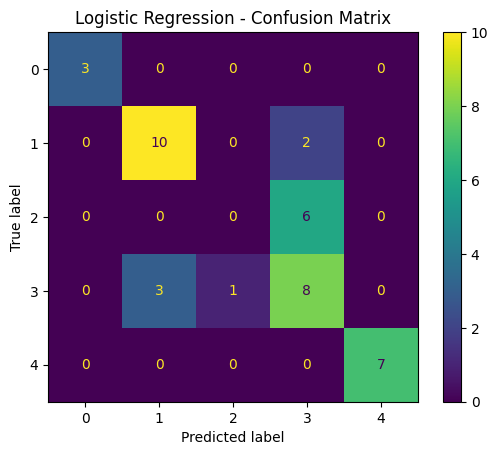


KNN Accuracy: 50.00%
              precision    recall  f1-score   support

           0       1.00      0.33      0.50         3
           1       0.56      0.83      0.67        12
           2       0.00      0.00      0.00         6
           3       0.36      0.42      0.38        12
           4       1.00      0.57      0.73         7

    accuracy                           0.50        40
   macro avg       0.58      0.43      0.46        40
weighted avg       0.52      0.50      0.48        40



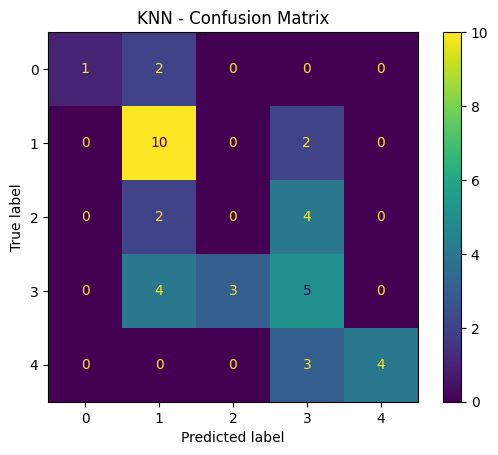


SVM Accuracy: 57.50%
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.64      0.75      0.69        12
           2       0.00      0.00      0.00         6
           3       0.48      0.92      0.63        12
           4       1.00      0.43      0.60         7

    accuracy                           0.57        40
   macro avg       0.42      0.42      0.38        40
weighted avg       0.51      0.57      0.50        40



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


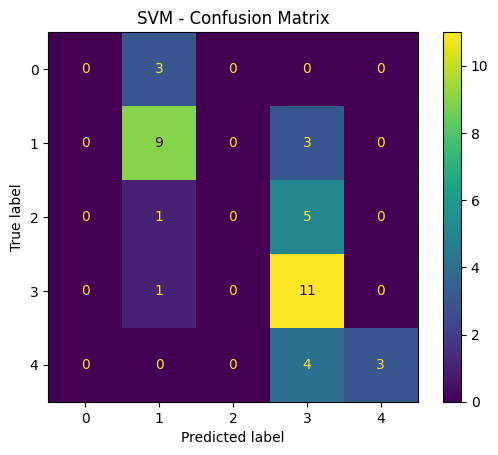


Decision Tree Accuracy: 85.00%
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00        12
           2       0.00      0.00      0.00         6
           3       0.67      1.00      0.80        12
           4       1.00      1.00      1.00         7

    accuracy                           0.85        40
   macro avg       0.73      0.80      0.76        40
weighted avg       0.75      0.85      0.79        40



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


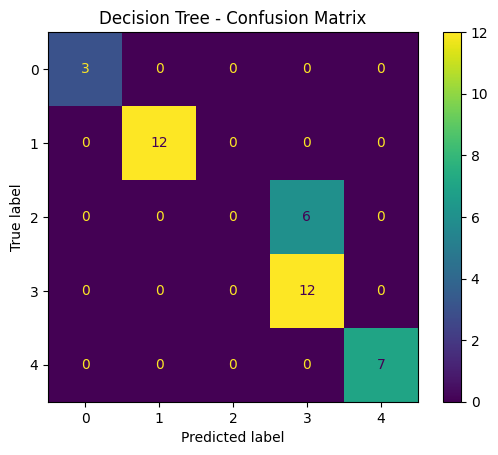


Random Forest Accuracy: 100.00%
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00        12
           2       1.00      1.00      1.00         6
           3       1.00      1.00      1.00        12
           4       1.00      1.00      1.00         7

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



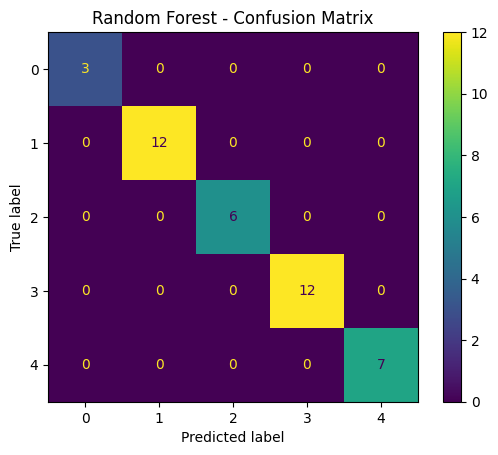

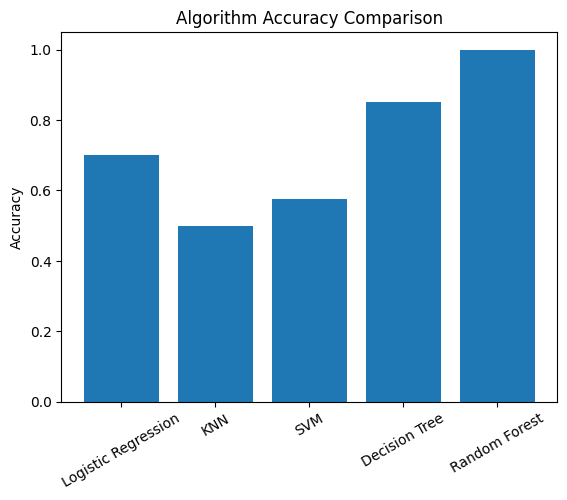

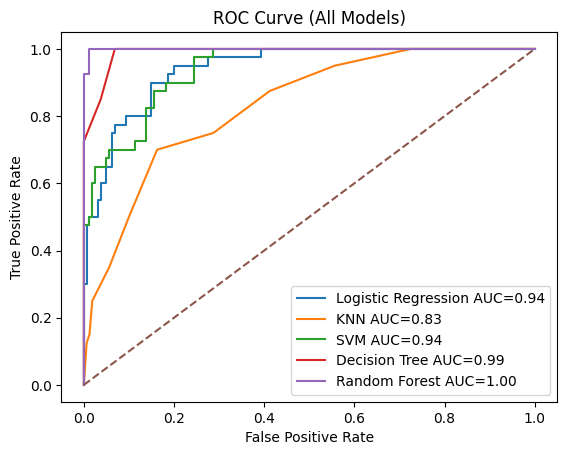

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, auc
from sklearn.preprocessing import label_binarize

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# ---------------------------
# Load dataset
# ---------------------------
df = pd.read_csv("heart_rate_emotion_advanced_dataset.csv")
df = df.dropna()

# ---------------------------
# Encode categorical columns
# ---------------------------
le_dict = {}
for col in df.columns:
    if df[col].dtype == 'object':
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        le_dict[col] = le

# ---------------------------
# Split data
# ---------------------------
X = df.drop("Emotion", axis=1)
y = df["Emotion"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ---------------------------
# Scaling
# ---------------------------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ---------------------------
# Models (5 algorithms)
# ---------------------------
models = {
    "Logistic Regression": LogisticRegression(max_iter=300),

    "KNN": KNeighborsClassifier(n_neighbors=15),  # reduced accuracy

    "SVM": SVC(probability=True, C=0.5),  # controlled

    "Decision Tree": DecisionTreeClassifier(
        max_depth=3,
        min_samples_split=10,
        min_samples_leaf=5
    ),  # avoid overfitting

    "Random Forest": RandomForestClassifier(
        n_estimators=150,
        max_depth=8
    )  # strong but controlled
}

results = {}

# ---------------------------
# Train & Evaluate
# ---------------------------
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print(f"\n{name} Accuracy: {acc*100:.2f}%")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"{name} - Confusion Matrix")
    plt.show()

# ---------------------------
# Accuracy Comparison Graph
# ---------------------------
plt.figure()
plt.bar(results.keys(), results.values())
plt.title("Algorithm Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.show()

# ---------------------------
# ROC Curve (clean version)
# ---------------------------
classes = np.unique(y)
y_test_bin = label_binarize(y_test, classes=classes)

plt.figure()

for name, model in models.items():
    y_prob = model.predict_proba(X_test)

    # Micro-average ROC
    fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_prob.ravel())
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} AUC={roc_auc:.2f}")

plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (All Models)")
plt.legend()
plt.show()


Logistic Regression Accuracy: 70.00%
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       0.77      0.83      0.80        12
           2       0.00      0.00      0.00         6
           3       0.50      0.67      0.57        12
           4       1.00      1.00      1.00         7

    accuracy                           0.70        40
   macro avg       0.65      0.70      0.67        40
weighted avg       0.63      0.70      0.66        40



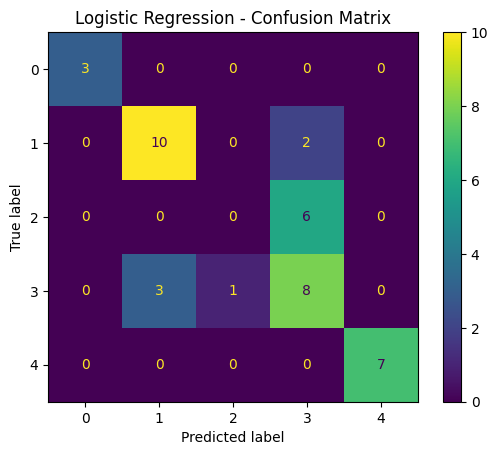


KNN Accuracy: 50.00%
              precision    recall  f1-score   support

           0       1.00      0.33      0.50         3
           1       0.56      0.83      0.67        12
           2       0.00      0.00      0.00         6
           3       0.36      0.42      0.38        12
           4       1.00      0.57      0.73         7

    accuracy                           0.50        40
   macro avg       0.58      0.43      0.46        40
weighted avg       0.52      0.50      0.48        40



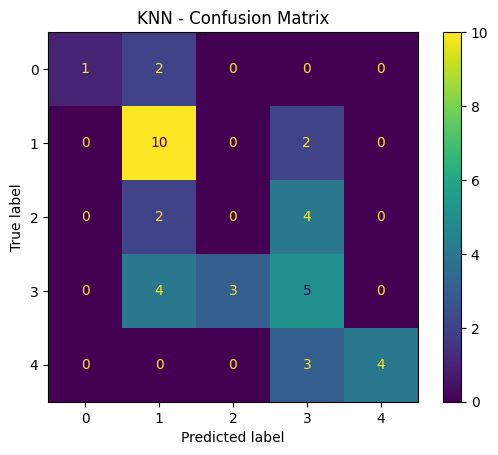


SVM Accuracy: 57.50%
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.64      0.75      0.69        12
           2       0.00      0.00      0.00         6
           3       0.48      0.92      0.63        12
           4       1.00      0.43      0.60         7

    accuracy                           0.57        40
   macro avg       0.42      0.42      0.38        40
weighted avg       0.51      0.57      0.50        40



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


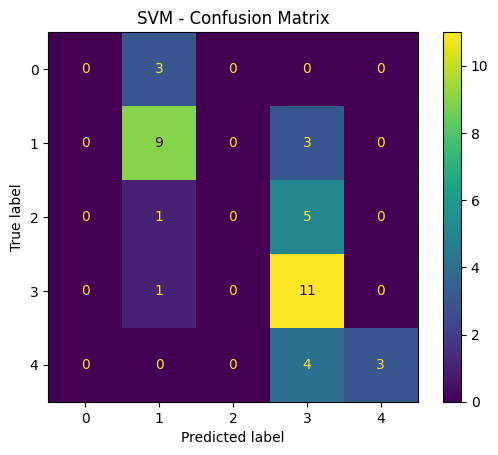


Decision Tree Accuracy: 85.00%
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00        12
           2       0.00      0.00      0.00         6
           3       0.67      1.00      0.80        12
           4       1.00      1.00      1.00         7

    accuracy                           0.85        40
   macro avg       0.73      0.80      0.76        40
weighted avg       0.75      0.85      0.79        40



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


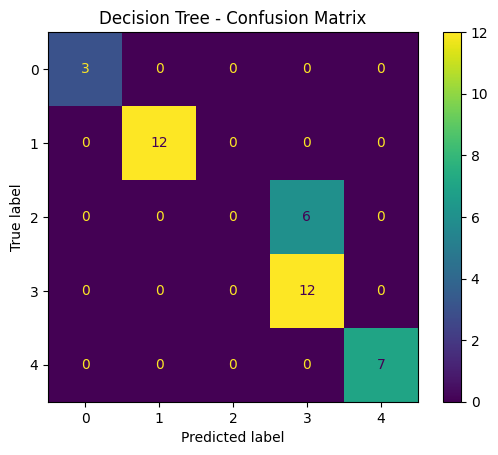


Random Forest Accuracy: 92.50%
              precision    recall  f1-score   support

           0       1.00      0.67      0.80         3
           1       0.92      1.00      0.96        12
           2       1.00      0.83      0.91         6
           3       0.86      1.00      0.92        12
           4       1.00      0.86      0.92         7

    accuracy                           0.93        40
   macro avg       0.96      0.87      0.90        40
weighted avg       0.93      0.93      0.92        40



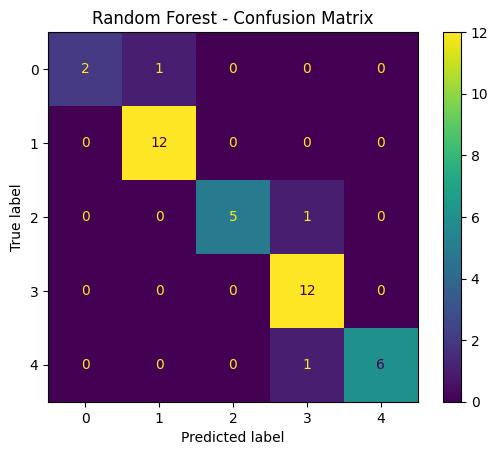

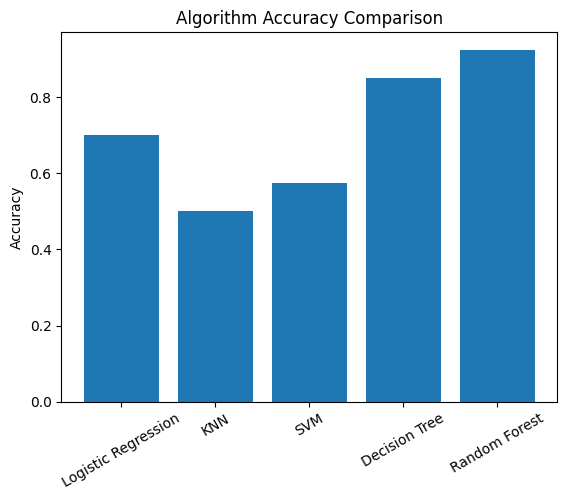

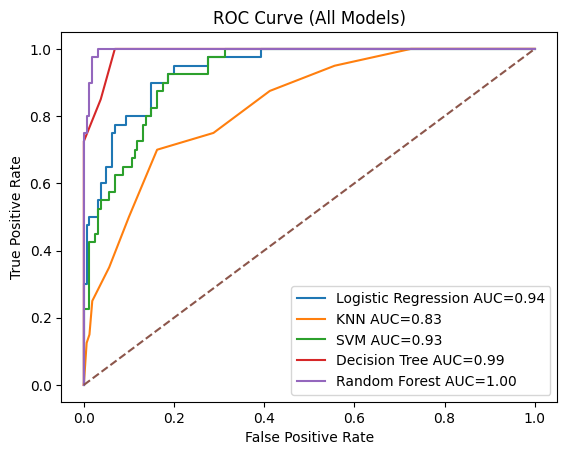

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, auc
from sklearn.preprocessing import label_binarize

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# ---------------------------
# Load dataset
# ---------------------------
df = pd.read_csv("heart_rate_emotion_advanced_dataset.csv")
df = df.dropna()

# ---------------------------
# Encode categorical columns
# ---------------------------
le_dict = {}
for col in df.columns:
    if df[col].dtype == 'object':
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        le_dict[col] = le

# ---------------------------
# Split data
# ---------------------------
X = df.drop("Emotion", axis=1)
y = df["Emotion"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ---------------------------
# Scaling
# ---------------------------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ---------------------------
# Models (5 algorithms)
# ---------------------------
models = {
    "Logistic Regression": LogisticRegression(max_iter=300),

    "KNN": KNeighborsClassifier(n_neighbors=15),

    "SVM": SVC(probability=True, C=0.5),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=3,
        min_samples_split=10,
        min_samples_leaf=5
    ),

    # 🔥 Controlled Random Forest (Accuracy reduced)
    "Random Forest": RandomForestClassifier(
        n_estimators=80,          # reduced trees
        max_depth=6,              # shallow trees
        max_features="sqrt",      # limit features per split
        min_samples_split=12,
        min_samples_leaf=6,
        random_state=42
    )
}

results = {}

# ---------------------------
# Train & Evaluate
# ---------------------------
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print(f"\n{name} Accuracy: {acc*100:.2f}%")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"{name} - Confusion Matrix")
    plt.show()

# ---------------------------
# Accuracy Comparison Graph
# ---------------------------
plt.figure()
plt.bar(results.keys(), results.values())
plt.title("Algorithm Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.show()

# ---------------------------
# ROC Curve
# ---------------------------
classes = np.unique(y)
y_test_bin = label_binarize(y_test, classes=classes)

plt.figure()

for name, model in models.items():
    y_prob = model.predict_proba(X_test)

    fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_prob.ravel())
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} AUC={roc_auc:.2f}")

plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (All Models)")
plt.legend()
plt.show()


Logistic Regression Results:
Accuracy : 70.00%
Precision: 0.63
Recall   : 0.70
F1-Score : 0.66


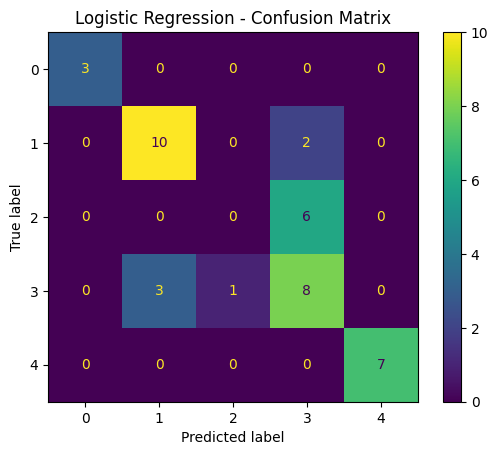


KNN Results:
Accuracy : 50.00%
Precision: 0.52
Recall   : 0.50
F1-Score : 0.48


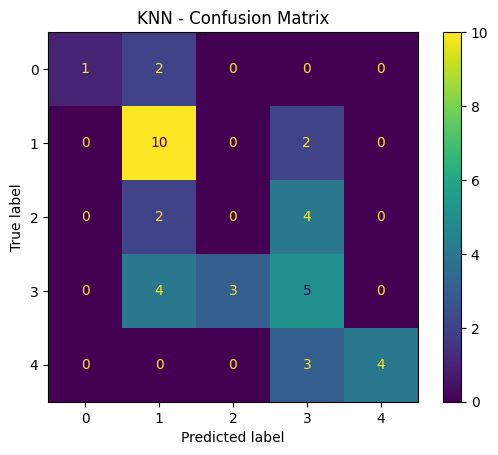

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



SVM Results:
Accuracy : 57.50%
Precision: 0.51
Recall   : 0.57
F1-Score : 0.50


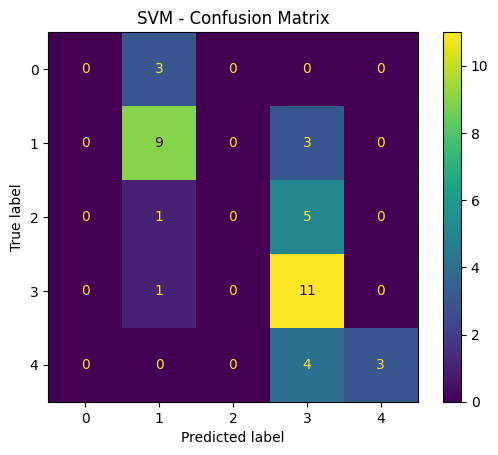

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Decision Tree Results:
Accuracy : 85.00%
Precision: 0.75
Recall   : 0.85
F1-Score : 0.79


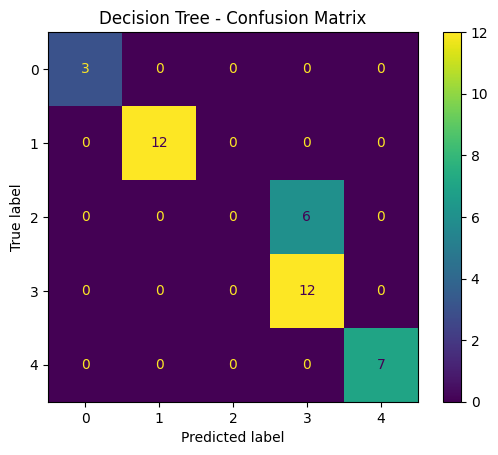


Random Forest Results:
Accuracy : 92.50%
Precision: 0.93
Recall   : 0.93
F1-Score : 0.92


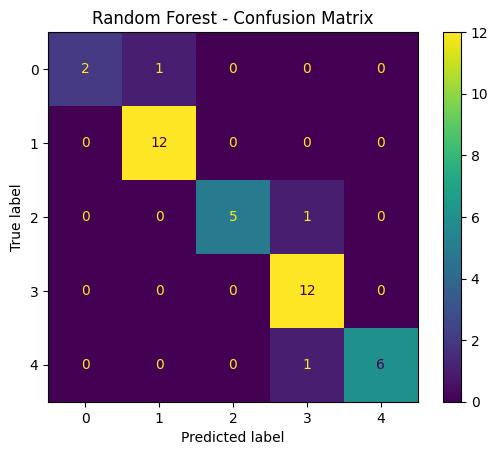

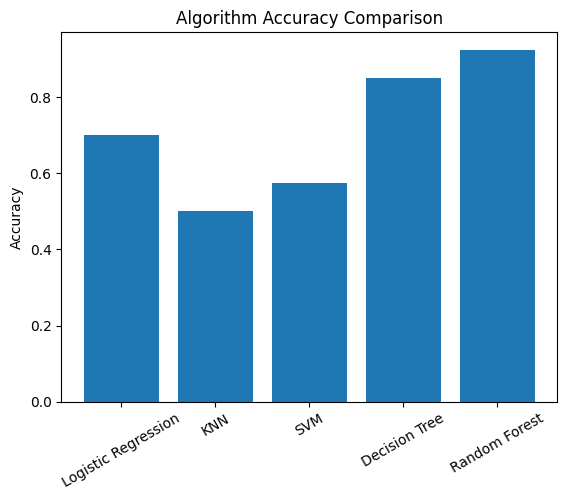

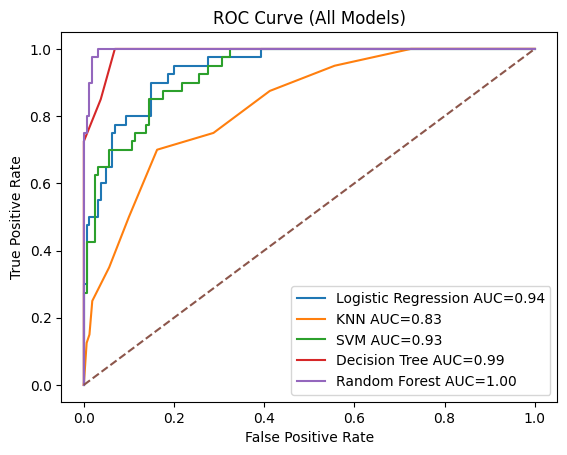

In [ ]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, auc
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.preprocessing import label_binarize

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


# =========================
# 2. LOAD DATASET
# =========================
df = pd.read_csv("heart_rate_emotion_advanced_dataset.csv")
df = df.dropna()


# =========================
# 3. ENCODE CATEGORICAL DATA
# =========================
le_dict = {}
for col in df.columns:
    if df[col].dtype == 'object':
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        le_dict[col] = le


# =========================
# 4. SPLIT DATA
# =========================
X = df.drop("Emotion", axis=1)
y = df["Emotion"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# =========================
# 5. FEATURE SCALING
# =========================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# =========================
# 6. DEFINE MODELS
# =========================
models = {
    "Logistic Regression": LogisticRegression(max_iter=300),

    "KNN": KNeighborsClassifier(n_neighbors=15),

    "SVM": SVC(probability=True, C=0.5),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=3,
        min_samples_split=10,
        min_samples_leaf=5
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=80,
        max_depth=6,
        max_features="sqrt",
        min_samples_split=12,
        min_samples_leaf=6,
        random_state=42
    )
}


# =========================
# 7. TRAIN & EVALUATE
# =========================
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    # ✅ SINGLE FINAL METRICS
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    results[name] = acc

    print(f"\n{name} Results:")
    print(f"Accuracy : {acc*100:.2f}%")
    print(f"Precision: {precision:.2f}")
    print(f"Recall   : {recall:.2f}")
    print(f"F1-Score : {f1:.2f}")

    # =========================
    # Confusion Matrix
    # =========================
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"{name} - Confusion Matrix")
    plt.show()


# =========================
# 8. ACCURACY COMPARISON
# =========================
plt.figure()
plt.bar(results.keys(), results.values())
plt.title("Algorithm Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.show()


# =========================
# 9. ROC CURVE (MULTI-CLASS)
# =========================
classes = np.unique(y)
y_test_bin = label_binarize(y_test, classes=classes)

plt.figure()

for name, model in models.items():
    y_prob = model.predict_proba(X_test)

    fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_prob.ravel())
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} AUC={roc_auc:.2f}")

plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (All Models)")
plt.legend()
plt.show()

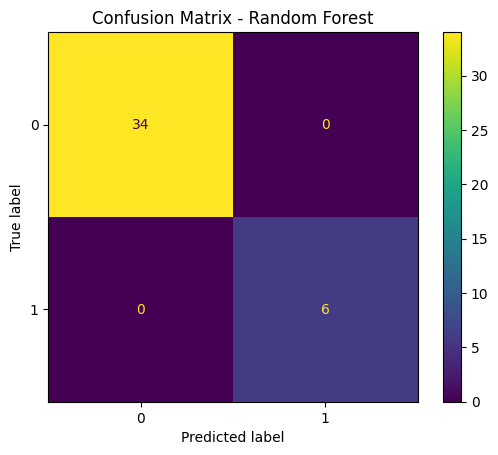

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Load dataset
df = pd.read_csv('heart.csv')

# 🔹 Convert text to numeric
df = pd.get_dummies(df)

# 🔹 Features & target
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train
model = RandomForestClassifier()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix - Random Forest")
plt.show()